In [ ]:
#===============================================================================
#1.IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay
#===============================================================================
#2.generate larger Farming Dataset
np.random.seed(42)
n_samples=60
data={
    'weather':np.random.choice(['sunny','cloudy','rainy'],n_samples),
    'soil':np.random.choice(['dry','moist','cool'],n_samples),
    'temperature':np.random.choice(['hot','mild','cool'],n_samples),
    'humidity':np.random.choice(['high','medium','low'],n_samples),
    'wind':np.random.choice(['strong','weak'],n_samples),
    'fertilizer':np.random.choice(['yes','no'],n_samples),
    'crop_type':np.random.choice(['wheat','rice','corn'],n_samples),
    'season':np.random.choice(['kharif','rabi','summer'],n_samples)
}
df=pd.DataFrame(data)
print(df)

   weather   soil temperature humidity    wind fertilizer crop_type season
0    rainy  moist         hot     high    weak        yes      corn   rabi
1    sunny    dry        cool      low    weak        yes      rice   rabi
2    rainy  moist        mild   medium  strong        yes      rice   rabi
3    rainy  moist        cool     high  strong        yes      rice   rabi
4    sunny  moist        cool     high    weak         no      rice   rabi
5    sunny  moist         hot     high  strong         no      rice   rabi
6    rainy  moist        cool      low    weak        yes     wheat   rabi
7   cloudy  moist         hot      low    weak         no      corn   rabi
8    rainy  moist        cool   medium  strong         no      rice   rabi
9    rainy    dry        mild      low  strong         no      corn   rabi
10   rainy   cool        cool     high    weak         no      corn   rabi
11   rainy  moist         hot   medium    weak        yes      rice   rabi
12   sunny  moist        

In [ ]:
#===============================================================================
#3.create target variable (rule based for realism)
def irrigation_rule(row):
  if row['soil']=='dry'and row['weather']!='rainy':
    return'yes'
  elif row['soil']=='wet':
    return'no'
  elif row['humidity']=='high'and row['weather']=='rainy':
    return'no'
  else:
    return np.random.choice(["yes","no"])
df["irrigate"]=df.apply(irrigation_rule,axis=1)
print("Sample Dataset:\n",df.head())






Sample Dataset:
   weather   soil temperature humidity    wind fertilizer crop_type season  \
0   rainy  moist         hot     high    weak        yes      corn   rabi   
1   sunny    dry        cool      low    weak        yes      rice   rabi   
2   rainy  moist        mild   medium  strong        yes      rice   rabi   
3   rainy  moist        cool     high  strong        yes      rice   rabi   
4   sunny  moist        cool     high    weak         no      rice   rabi   

  irrigate  
0       no  
1      yes  
2       no  
3       no  
4      yes  


In [ ]:
#===============================================================================
#4.encode categorical variables
le_dict={}
for column in df.columns:
  le=LabelEncoder()
  df[column]=le.fit_transform(df[column])
  le_dict[column]=le
#===============================================================================
#5 split features and target
X=df.drop('irrigate',axis=1)
y=df['irrigate']
#===============================================================================
#6 train test split (stratified)
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.3,random_state=42,stratify=y
    )
#===============================================================================
#7 decision tree model
dt_model=DecisionTreeClassifier(criterion='entropy',random_state=42)
dt_model.fit(X_train,y_train)

y_pred_dt=dt_model.predict(X_test)
#==============================================================================
#8 random forest classifer
rf_model=RandomForestClassifier(
    n_estimators=20,
    criterion='entropy',
    random_state=42
)
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)




In [ ]:
#===============================================================================
#9 accuracy evaluation
dt_accuracy=accuracy_score(y_test,y_pred_dt)
rf_accuracy=accuracy_score(y_test,y_pred_rf)
print('\nAccuracy comparison:')
print("Decision Tree accuracy :",dt_accuracy)
print("random Forest Accuracy:",rf_accuracy)


Accuracy comparison:
Decision Tree accuracy : 0.5555555555555556
random Forest Accuracy: 0.5555555555555556


In [ ]:
#10 confusion marix (fixed + meaningfull )
cm_dt=confusion_matrix(y_test,y_pred_dt,labels=[0,1])
cm_rf=confusion_matrix(y_test,y_pred_dt,labels=[0,1])
cm_dt_df=pd.DataFrame(
    cm_dt,index=['Actual No','Actual Yes'],columns=['Pred No','Pred Yes']
    )
cm_rf_df=pd.DataFrame(
    cm_rf,index=['Actual No','Actual Yes'],columns=['Pred No','Pred Yes']
    )
print("\n Decision Tree Confusion Matrix :\n ", cm_dt_df)
print("\n Random Forest Confusion Matrix :\n ", cm_rf_df)







 Decision Tree Confusion Matrix :|n              Pred No  Pred Yes
Actual No         8         1
Actual Yes        7         2

 Random Forest Confusion Matrix :|n              Pred No  Pred Yes
Actual No         8         1
Actual Yes        7         2


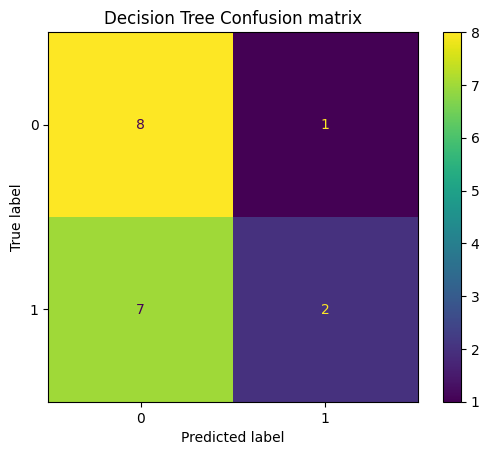

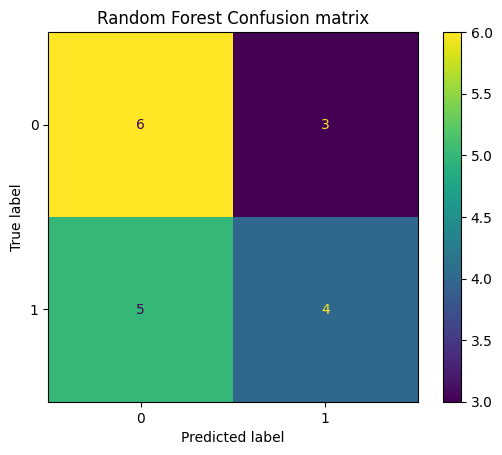

In [ ]:
#11 confusion matrix visualization
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt,labels=[0,1])
plt.title("Decision Tree Confusion matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_rf,labels=[0,1])
plt.title("Random Forest Confusion matrix")
plt.show()

In [ ]:
# 12 CROSS VALAIDATION
dt_cv=cross_val_score(dt_model,X,y,cv=5)
rf_cv=cross_val_score(rf_model,X,y,cv=5)
print("\n Cross validation accuracy:")
print("Decision Tree:",dt_cv.mean())
print("random Forest:",rf_cv.mean())

# 13 important feature
importance=pd.DataFrame({
    'feature':X.columns,
    'importance':rf_model.feature_importances_}).sort_values(
        by='importance',ascending=False)

print("\n Feature importance :\n ",importance)



 Cross validation accuracy:
Decision Tree: 0.5833333333333334
random Forest: 0.55

 Feature importance :
         feature  importance
3     humidity    0.195128
2  temperature    0.177505
1         soil    0.173661
6    crop_type    0.142303
0      weather    0.141020
5   fertilizer    0.087047
4         wind    0.083337
7       season    0.000000
